In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pd.read_parquet("../ClearData/train_full.parquet")
train_part1.shape

(85677840, 14)

In [3]:
train_part1.info()

<class 'pandas.DataFrame'>
RangeIndex: 85677840 entries, 0 to 85677839
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   event_type_nm               int16  
 1   event_desc                  int32  
 2   channel_indicator_type      int16  
 3   channel_indicator_sub_type  int16  
 4   operaton_amt                float64
 5   currency_iso_cd             int16  
 6   mcc_code                    int16  
 7   pos_cd                      int16  
 8   developer_tools             int32  
 9   phone_voip_call_state       int32  
 10  web_rdp_connection          int16  
 11  compromised                 int16  
 12  Hour                        int16  
 13  target                      int16  
dtypes: float64(1), int16(10), int32(3)
memory usage: 3.2 GB


In [4]:
train_part1["target"].value_counts()

target
0    85626402
1       51438
Name: count, dtype: int64

In [5]:
pos_class = train_part1.loc[train_part1["target"] == 1]
pos_class.shape

(51438, 14)

In [6]:
train_part1 = train_part1.loc[train_part1["target"] != 1]
train_part1.shape

(85626402, 14)

In [7]:
neg_class = 15_000_000
train_part1 = train_part1.sample(n=neg_class)
train_part1 = pd.concat([train_part1, pos_class])
train_part1 = train_part1.sample(frac=1).reset_index(drop=True)
train_part1.shape

(15051438, 14)

In [9]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   

In [11]:
del train_part1, x, y
gc.collect()

0

In [12]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [13]:
CatBoost = CatBoostClassifier(iterations=15, depth=2, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8698624878509207
Precision: 0.012253702734479998
Recall: 0.46578390288158295
F1-score: 0.02387919869635057
PR-AUC: 0.020764123661821465

Test metrics:
Accuracy: 0.8700695747383639
Precision: 0.012028865176255933
Recall: 0.4562597200622084
F1-score: 0.02343976270610912
PR-AUC: 0.02022070698474237

Confusion matrix


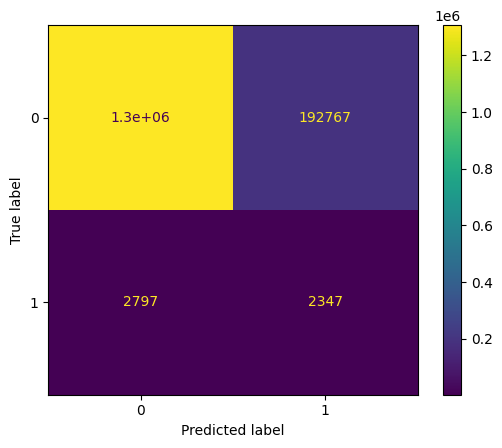

In [14]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [15]:
CatBoost = CatBoostClassifier(iterations=15, depth=3, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8634599987273271
Precision: 0.012811639026356498
Recall: 0.5121830042770121
F1-score: 0.024997983693483456
PR-AUC: 0.0240786924074656

Test metrics:
Accuracy: 0.8636097277071164
Precision: 0.012709202728826518
Recall: 0.5073872472783826
F1-score: 0.024797275149995014
PR-AUC: 0.023360849204524768

Confusion matrix


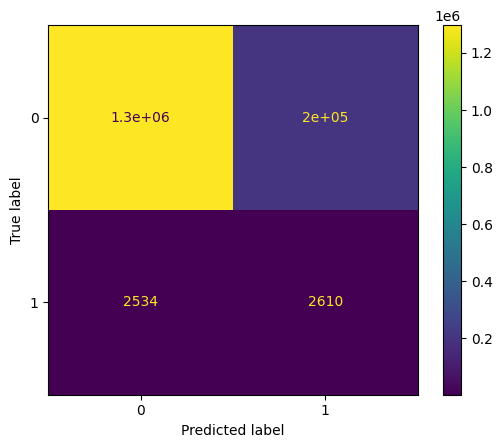

In [16]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [17]:
CatBoost = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8629171934405085
Precision: 0.012975869756072369
Recall: 0.5210394435564004
F1-score: 0.025321146374722735
PR-AUC: 0.024128060058086258

Test metrics:
Accuracy: 0.8629719149795634
Precision: 0.012942789190445975
Recall: 0.5194401244167963
F1-score: 0.02525627271481301
PR-AUC: 0.023079082245753925

Confusion matrix


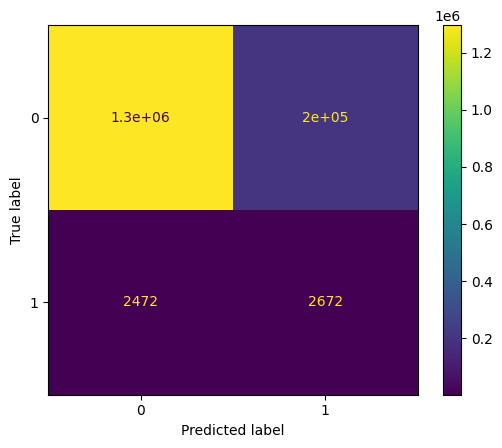

In [18]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [19]:
CatBoost = CatBoostClassifier(iterations=50, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8203742662015161
Precision: 0.011138086135024308
Recall: 0.5873763338661597
F1-score: 0.021861622649837376
PR-AUC: 0.032783175840203876

Test metrics:
Accuracy: 0.8204510664760315
Precision: 0.011130822198208299
Recall: 0.5867029548989113
F1-score: 0.021847163958694526
PR-AUC: 0.029886785542260257

Confusion matrix


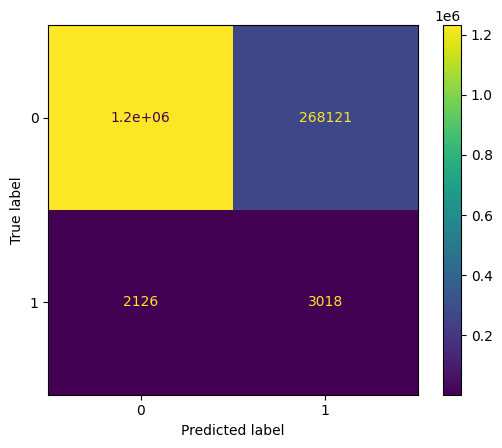

In [20]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Для моделей с auto_class_weights='Balanced' глубина 4 давала наилучшие результаты при числе итераций 15

Попробуем настроить веса меток самостоятельно

In [21]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=15, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9539007495334149
Precision: 0.02766622116638292
Recall: 0.365770942238735
F1-score: 0.05144150438982897
PR-AUC: 0.029905189761703872

Test metrics:
Accuracy: 0.9540170242847196
Precision: 0.027327322896224047
Recall: 0.36003110419906686
F1-score: 0.05079887540286635
PR-AUC: 0.027565637798175547

Confusion matrix


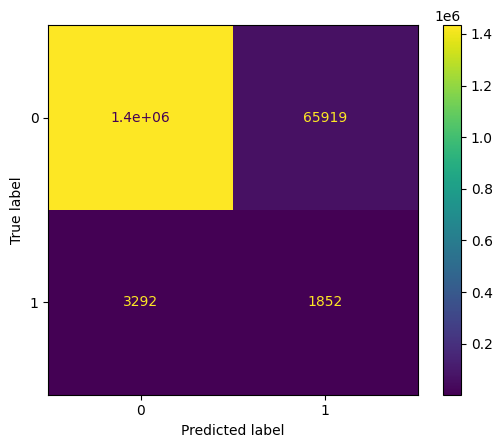

In [22]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [23]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9533549175885301
Precision: 0.03063661838165041
Recall: 0.4128180757765585
F1-score: 0.057040099091166856
PR-AUC: 0.041391141878038745

Test metrics:
Accuracy: 0.9533798759454245
Precision: 0.029982363315696647
Recall: 0.4031881804043546
F1-score: 0.05581420382679835
PR-AUC: 0.03584881532164652

Confusion matrix


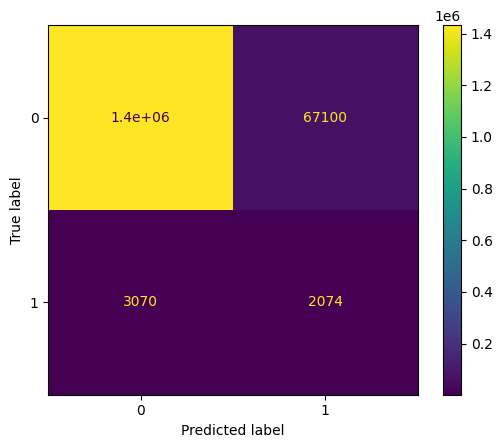

In [24]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [25]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.2570168638005347
Precision: 0.004365163861109484
Recall: 0.9529744675335897
F1-score: 0.00869052020791691
PR-AUC: 0.035826815666313835

Test metrics:
Accuracy: 0.2571840302323233
Precision: 0.004345932291105314
Recall: 0.9484836702954899
F1-score: 0.008652220290245725
PR-AUC: 0.03248558428647792

Confusion matrix


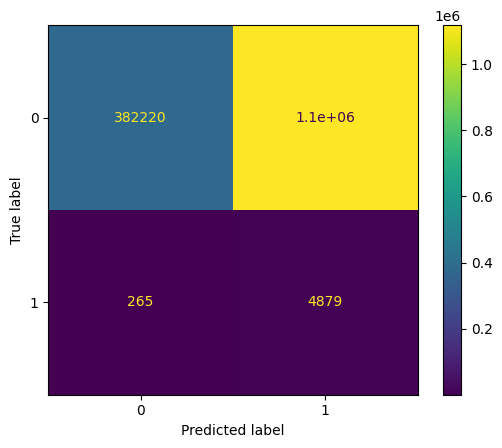

In [26]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [27]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=200, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.26953283311287946
Precision: 0.004460287052739846
Recall: 0.9574458893161101
F1-score: 0.008879210070022639
PR-AUC: 0.0393456833961871

Test metrics:
Accuracy: 0.2695117543570582
Precision: 0.004395626292964461
Recall: 0.9434292379471229
F1-score: 0.008750482331346308
PR-AUC: 0.03446241493851419

Confusion matrix


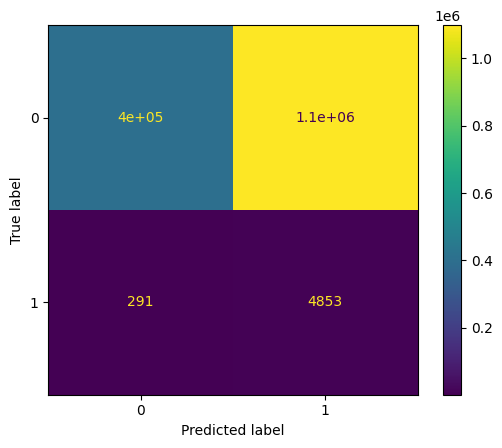

In [28]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [29]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.09456830037794839
Precision: 0.0036982934690018734
Recall: 0.9834103771547069
F1-score: 0.007368874944400814
PR-AUC: 0.024392939895257988

Test metrics:
Accuracy: 0.09509455573685972
Precision: 0.0037044704560434297
Recall: 0.9844479004665629
F1-score: 0.0073811656382252264
PR-AUC: 0.023828132122914195

Confusion matrix


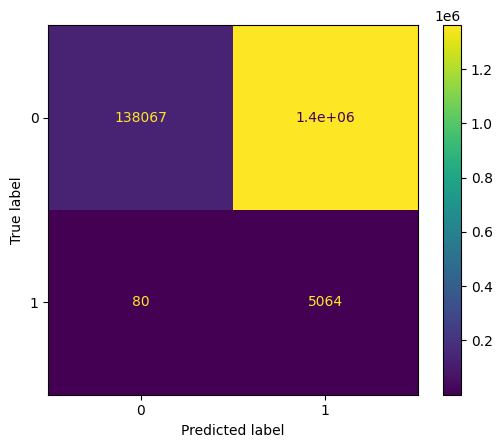

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [31]:
weights = {0: 1, 1: 800}
CatBoost = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.3325998239813782
Precision: 0.004746654749831814
Recall: 0.9310709811206636
F1-score: 0.009445157529770171
PR-AUC: 0.03819673221672126

Test metrics:
Accuracy: 0.33299870311412066
Precision: 0.0047080036061304216
Recall: 0.9228227060653188
F1-score: 0.009368213003995355
PR-AUC: 0.0342850167029738

Confusion matrix


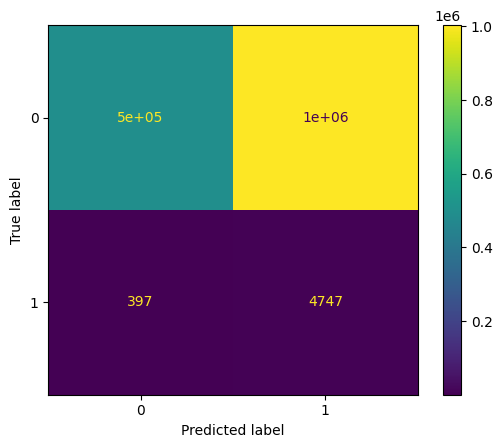

In [32]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [33]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.42504281982954156
Precision: 0.005151198944526405
Recall: 0.8704583747353869
F1-score: 0.010241789025550846
PR-AUC: 0.02650823340346999

Test metrics:
Accuracy: 0.42586755818712363
Precision: 0.0051694620395353824
Recall: 0.8722783825816485
F1-score: 0.010278012566342086
PR-AUC: 0.025087361478028307

Confusion matrix


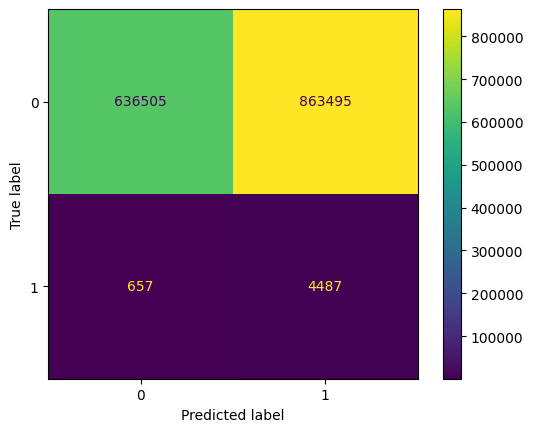

In [34]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [35]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.5465379682443036
Precision: 0.006207282208922883
Recall: 0.8277098544087786
F1-score: 0.01232215630982322
PR-AUC: 0.03951296762634009

Test metrics:
Accuracy: 0.5468347214618667
Precision: 0.0061673006132284
Recall: 0.8217340590979783
F1-score: 0.012242716857847488
PR-AUC: 0.034657862928350665

Confusion matrix


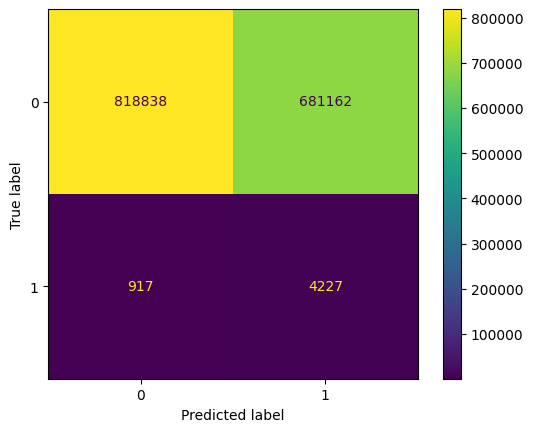

In [36]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Из последних показателей могу сделать вывод, что увеличение числа деревьев в ансамбле (после некоторого значения деревьев) сильного эффекта уже не дает, т.е. есть конкретный предел точночти, к которому при постоянном увеличении кол-ва деревьев модель стремится  